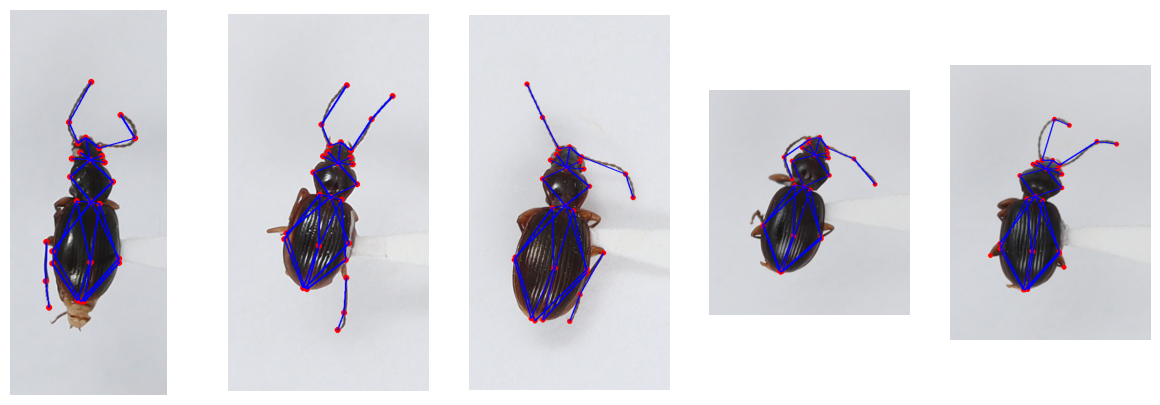

In [69]:
import os
import matplotlib.pyplot as plt
import yaml
import pathlib
import PIL.Image as Image, PIL.ImageDraw as ImageDraw

def visualize_annotation(dataset_name, num, dataset_dir = "../models/datasets/", split_dir="train", show_kp=True, show_lines=True):
    dataset_path = pathlib.Path(dataset_dir) / dataset_name 
    showed_images = sorted(( dataset_path / "images" / split_dir).glob("*.png"))[:num]
    showed_labels = sorted((dataset_path / "labels" / split_dir).glob("*.txt"))[:num]
    config = yaml.safe_load(open(dataset_path / "yolo-config.yaml", "r"))
    skeleton = config.get("skeleton", [])
    
    fig, axes = plt.subplots(1, num, figsize=(15, 5))

    for img_name, label_name in zip(showed_images, showed_labels):

        img = Image.open(img_name)
        w, h = img.size

        # draw bbox
        draw = ImageDraw.Draw(img)
        with open(label_name, "r") as f:
            for line in f:
                line = line.strip().split()
                cls, x_center, y_center, width, height = line[:5]
                if show_kp:
                    kpts = line[5:]
                    kpts = [float(kpt) for kpt in kpts]
                    kpts = list(zip(kpts[0::3], kpts[1::3], kpts[2::3])) # (x,y,visible)
                    for x, y, v in kpts:
                        if v > 0:
                            draw.ellipse((x*w-5, y*h-5, x*w+5, y*h+5), fill="red")
                    
                    if show_lines:
                        for idx1, idx2 in skeleton:
                            x1, y1, v1 = kpts[idx1]
                            x2, y2, v2 = kpts[idx2]
                            if v1 > 0 and v2 > 0:
                                draw.line((x1*w, y1*h, x2*w, y2*h), fill="blue", width=3)

        axes[showed_images.index(img_name)].imshow(img)
        axes[showed_images.index(img_name)].axis("off")
    
    plt.show()

visualize_annotation("fuzed", num=5, split_dir="train", show_kp=True, show_lines=True)


In [1]:
from ultralytics import YOLO
import time as t
import os
import numpy as np
from glob import glob
import cv2
import json
import yaml
from pathlib import Path

DATASET_NAME = "fuzed-noleg-noHwing"

#  MODEL_PATH = "./runs/pose/train/weights/best.pt"
TEST_IMAGES = f"./datasets/{DATASET_NAME}/images/test/"
TEST_LABELS = f"./datasets/{DATASET_NAME}/labels/test/"

IMG_SIZE = 640
CONF = 0.25
DIST_THRESHOLD = 0.05  # seuil normalisé (5% de la bbox)

all_kp = [
    "head-top", "head-left","head-right","left-eye","right-eye","neck","thorax-left","thorax-right","thorax-bottom","body-left","body-right",
    "body-tip","left-antenna-0","left-antenna-1","left-antenna-2","right-antenna-0","right-antenna-1","right-antenna-2","left-forewing-base","left-forewing-tip","left-forewing-front",
    "left-forewing-rear","right-forewing-base","right-forewing-tip","right-forewing-front","right-forewing-rear","left-hindwing-base","left-hindwing-tip","left-hindwing-front","left-hindwing-rear",
    "right-hindwing-base","right-hindwing-tip","right-hindwing-front","right-hindwing-rear","left-leg-0","left-leg-1","left-leg-2","left-leg-3","right-leg-0","right-leg-1","right-leg-2","right-leg-3",
]

# model = YOLO(MODEL_PATH)

def load_yolo_pose_label(label_path):
    """
    Format YOLO pose :
    class cx cy w h kpt1_x kpt1_y v1 kpt2_x kpt2_y v2 ...
    """
    with open(label_path, "r") as f:
        line = f.readline().strip().split()

    values = list(map(float, line))

    # bbox
    cx, cy, w, h = values[1:5]

    # keypoints
    kpts = np.array(values[5:]).reshape(-1, 3)[:, :2]  # (x, y)

    return np.array([cx, cy, w, h]), kpts


def denormalize(kpts, img_w, img_h):
    kpts[:, 0] *= img_w
    kpts[:, 1] *= img_h
    return kpts


def bbox_size_pixels(bbox, img_w, img_h):
    _, _, w, h = bbox
    return np.sqrt((w * img_w) * (h * img_h))


def check_keywords(name, kws):
    count = 0
    for kw in kws:
        if kw in name :
            count += 1
    return count == len(kws)

In [ ]:
base_model = "yolo26s-pose"
params = {
"pose":98.0, # base value = 12.0
"kws": "500epochs-noleg-noHwing",
}

model = base_model + "_" + "_".join([param + str(value) for param, value in params.items()])

with open("run_results.json") as f:
    all_models = json.load(f)

if model not in all_models:
    all_models[model] = {"name" : f"{base_model}.pt", "training time" : 0, "keypoints perf":[], "metrics" : []}
else:
    all_models[model + "-a"] = {"name" : f"{base_model}.pt", "training time" : 0, "keypoints perf":[], "metrics" : []}

print(f"\nTraining {model}")
loaded_model = YOLO(all_models[model]["name"])

T1 = t.time()
config_file = f"./datasets/{DATASET_NAME}/yolo-config.yaml"

with open(config_file, "r") as f:
    data = yaml.safe_load(f)
    current_kp = data["kpt_names"][0]

results_yolo = loaded_model.train(
    data        = config_file, 
    epochs      = 500, 
    imgsz       = 640,
    pose        = params["pose"])

all_models[model]['traning time'] = t.time() - T1

all_errors = []

image_paths = glob(os.path.join(TEST_IMAGES, "*.jpg")) + glob(os.path.join(TEST_IMAGES, "*.png"))

for img_path in image_paths:
    label_path = os.path.join(
        TEST_LABELS,
        os.path.basename(img_path).replace(".jpg", ".txt").replace(".png", ".txt")
    )

    if not os.path.exists(label_path):
        continue

    # Load GT
    bbox_gt, kpts_gt = load_yolo_pose_label(label_path)

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    kpts_gt = denormalize(kpts_gt.copy(), w, h)

    # Predict
    res_yolo = loaded_model.predict(img_path, conf=CONF, verbose=True)

    if len(res_yolo[0].keypoints) != 0:
        kpts_pred = res_yolo[0].keypoints.xy[0].cpu().numpy()
        errors = np.linalg.norm(kpts_pred - kpts_gt, axis=1)
        completed_errors = []
        idx = 0
        for i in range(len(all_kp)):
            if all_kp[i] in current_kp:
                completed_errors.append(errors[idx])
                idx += 1
            else:
                completed_errors.append(0)

        all_errors.append(completed_errors)

all_errors = np.array(all_errors)

all_models[model]["keypoints perf"] = all_errors.mean(axis=0).tolist()

with open("run_results.json", "w") as f:
    json.dump(all_models, f, indent=2)



Training yolo26s-pose_pose98.0_kws500epochs-noleg-noHwing
New https://pypi.org/project/ultralytics/8.4.36 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.33 🚀 Python-3.12.3 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060, 7805MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./datasets/fuzed-noleg-noHwing/yolo-config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=500, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

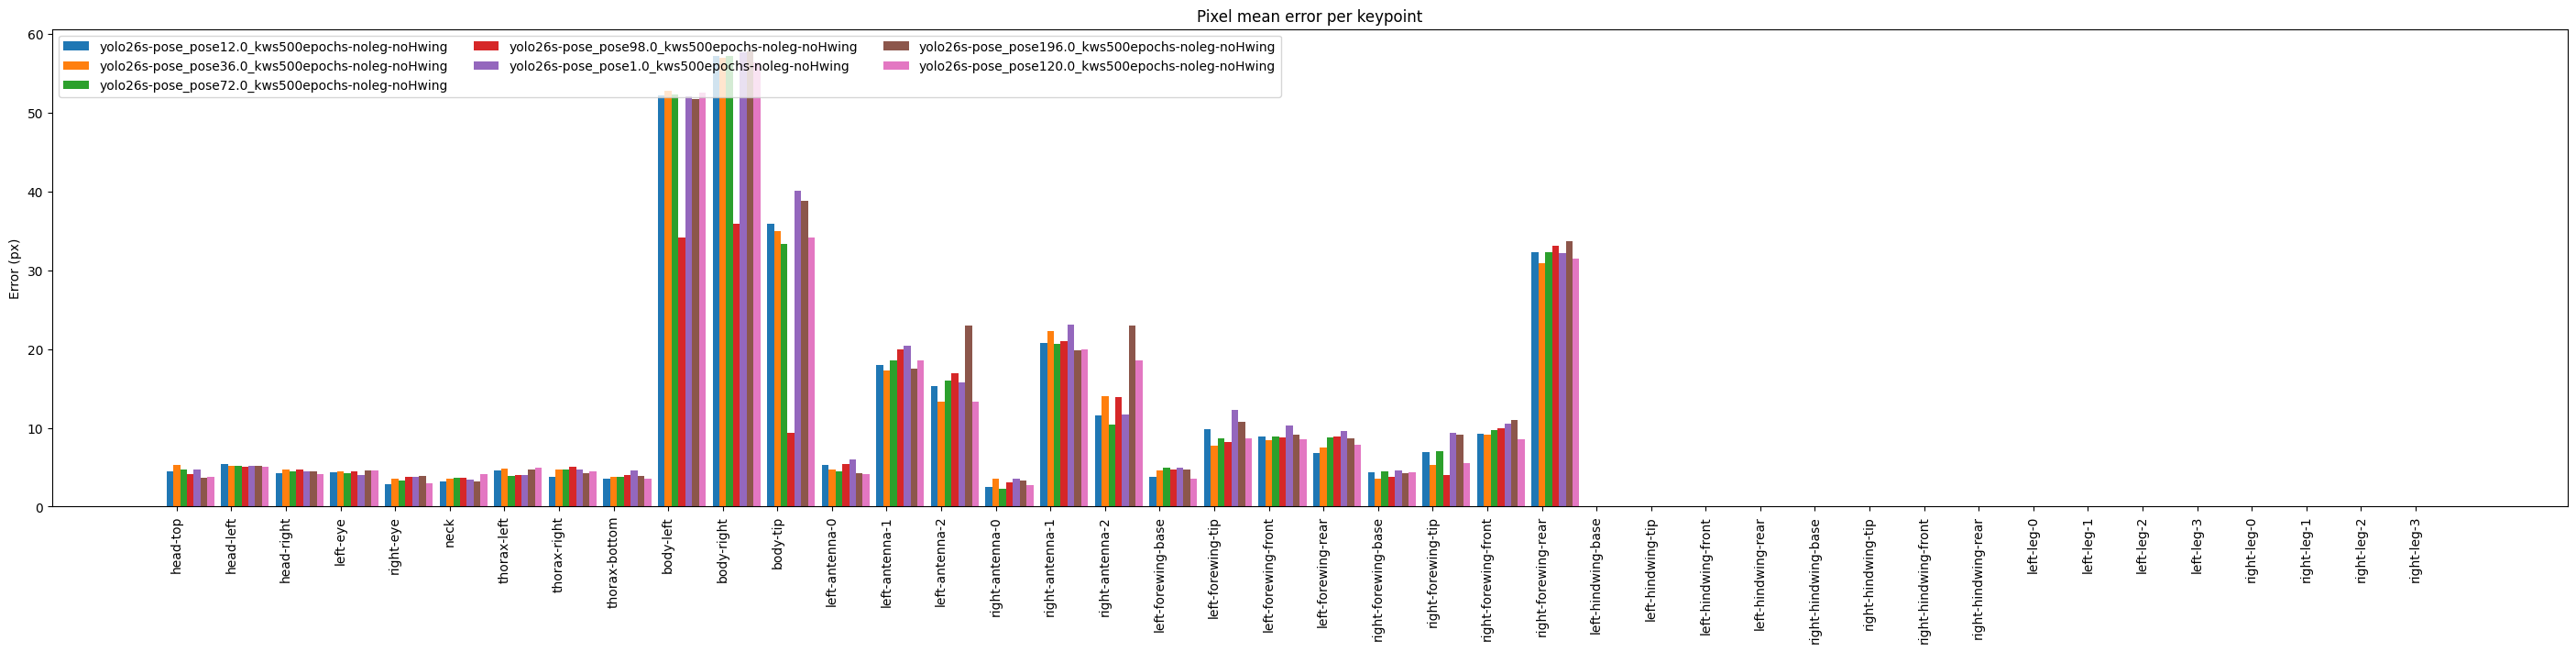

In [2]:
import matplotlib.pyplot as plt
import yaml

filter =  ["yolo26s", "noleg", "noHwing"]

with open(f"./datasets/{DATASET_NAME}/yolo-config.yaml", "r") as f:
    config = yaml.safe_load(f)

with open("run_results.json", "r") as f:
    models_data = json.load(f)

x = np.arange(42)  # the label locations

filtered_models = [x for x in list(models_data.items()) if check_keywords(x[0], filter)]
number_of_models = len(filtered_models)
width = 1/(number_of_models + 1)  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(4*number_of_models, 7))

for attribute, measurement in filtered_models:
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement["keypoints perf"], width, label=attribute)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Error (px)')
ax.set_title('Pixel mean error per keypoint')
ax.set_xticks(x + width, all_kp, rotation=90)
ax.legend(loc='upper left', ncols=3)

plt.show()

fig.savefig("perf_comparison_results.png")
plt.show()

/tmp/ipykernel_504984/3752254240.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


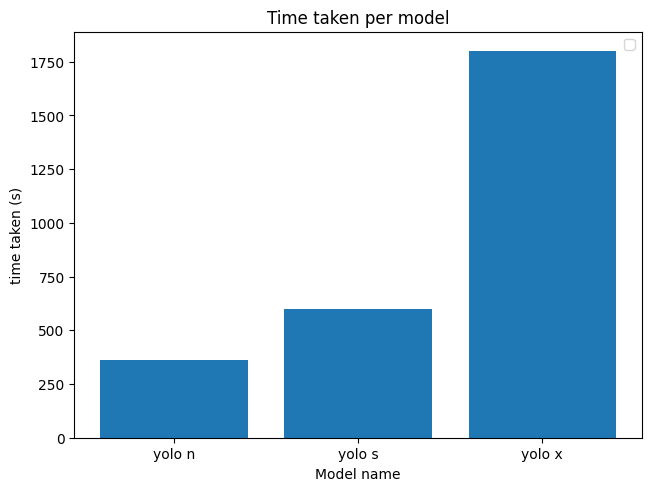

In [8]:
fig, ax = plt.subplots(layout="constrained")

ax.bar(["yolo n", "yolo s", "yolo x"], [models_data["yolo26n-pose"]["training time"], models_data["yolo26s-pose"]["training time"], models_data["yolo26x-pose"]["training time"]]
)
ax.set_xlabel("Model name")
ax.set_ylabel("time taken (s)")
ax.set_title("Time taken per model")
ax.legend()


fig.savefig("time_comparison.png")
plt.show()

In [51]:
# Save results
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

base_path = Path("./runs/pose")

csv_files = list(base_path.glob("run-*/**/*.csv"))

for csv_file in csv_files:
    print("Processing " + str(csv_file))
    df = pd.read_csv(csv_file)

    fig, axes = plt.subplots(2, 10, figsize=(20, 8))
    axes = axes.flatten()

    for i in range(20):
        ax = axes[i]
        ax.plot(df.iloc[:, i+2])
        ax.set_title(df.columns[i+2])

    plt.tight_layout()

    # Sauvegarde dans le même dossier que le CSV
    output_path = csv_file.parent / "results_v2.png"
    plt.savefig(output_path)
    plt.close(fig)

Processing runs/pose/run-100-yolo26n-noskeleton/results.csv
Processing runs/pose/run-200-yolo26s-pose24-500epochs/results.csv
Processing runs/pose/run-200-yolo26x/results.csv
Processing runs/pose/run-200-yolo26s-pose98-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-100-yolo26n/results.csv
Processing runs/pose/run-200-yolo26s-pose100/results.csv
Processing runs/pose/run-200-yolo26s-pose72-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-200-yolo26s-500epochs/results.csv
Processing runs/pose/run-200-yolo26s-pose196-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-200-yolo26s-pose1-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-200-yolo26n/results.csv
Processing runs/pose/run-200-yolo26s-pose36-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-200-yolo26s-pose1-500epochs/results.csv
Processing runs/pose/run-200-yolo26s-500epochs-noleg-noHwing/results.csv
Processing runs/pose/run-200-yolo26s/results.csv
Processing runs/pose/run

In [3]:
# show differences
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import math

def check_keywords(name, kws):
    count = 0
    for kw in kws:
        if kw in name :
            count += 1
    return count == len(kws)

def plot_columns(cols_to_plot, filter_kws = []):

    base_path = Path("./runs/pose")

    # Récupération des CSV
    csv_files = list(base_path.glob("run-*/*.csv"))

    data = {}
    for csv_file in csv_files:
        run_name = csv_file.parent.name
        df = pd.read_csv(csv_file)
        data[run_name] = df

    n_plots = len(cols_to_plot)

    n_rows = 2
    n_cols = math.ceil(n_plots / n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = axes.flatten()

    for idx, col_idx in enumerate(cols_to_plot):
        ax = axes[idx]
        sorted_data_items = [x for x in list(data.items()) if check_keywords(x[0], filter_kws)]
        sorted_data_items.sort(key=lambda x: x[0])
        for run_name, df in sorted_data_items:
            if col_idx < df.shape[1]:
                ax.plot(df.iloc[:, col_idx], label=run_name)

        first_df = next(iter(data.values()))
        ax.set_title(first_df.columns[col_idx])
        ax.legend()

    # Supprimer les axes inutilisés
    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

preset_train = [2, 3, 4, 5, 6, 7]
preset_val = [16, 17, 18, 19, 20, 21]
preset_metrics_box = [8, 9, 10, 11]
preset_metrics_pose = [12, 13, 14, 15]

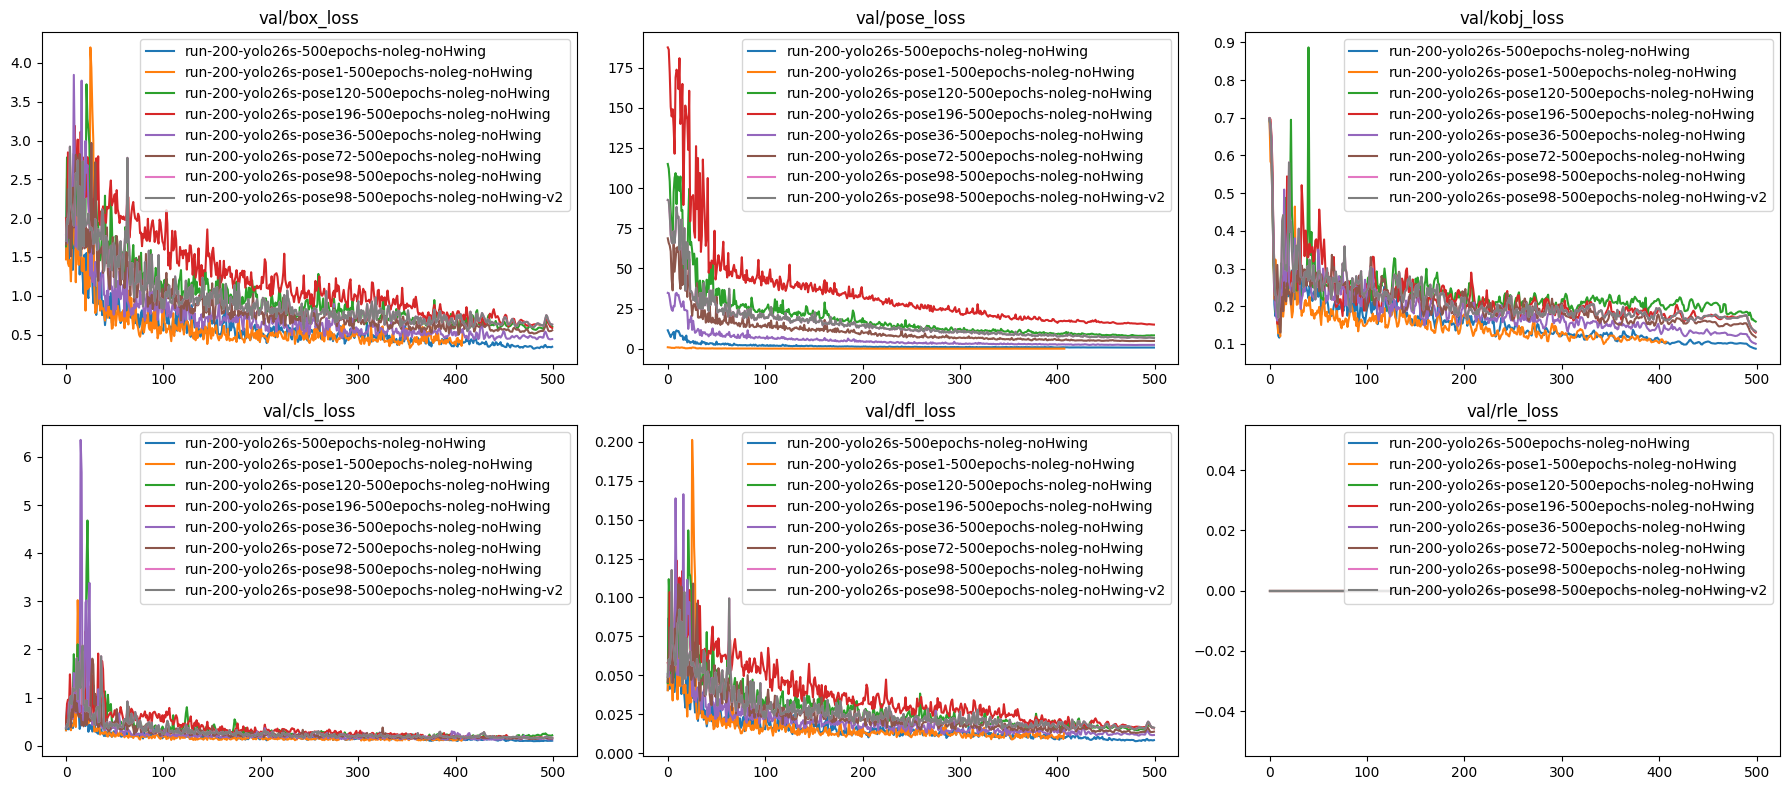

In [5]:
plot_columns(preset_val, filter)

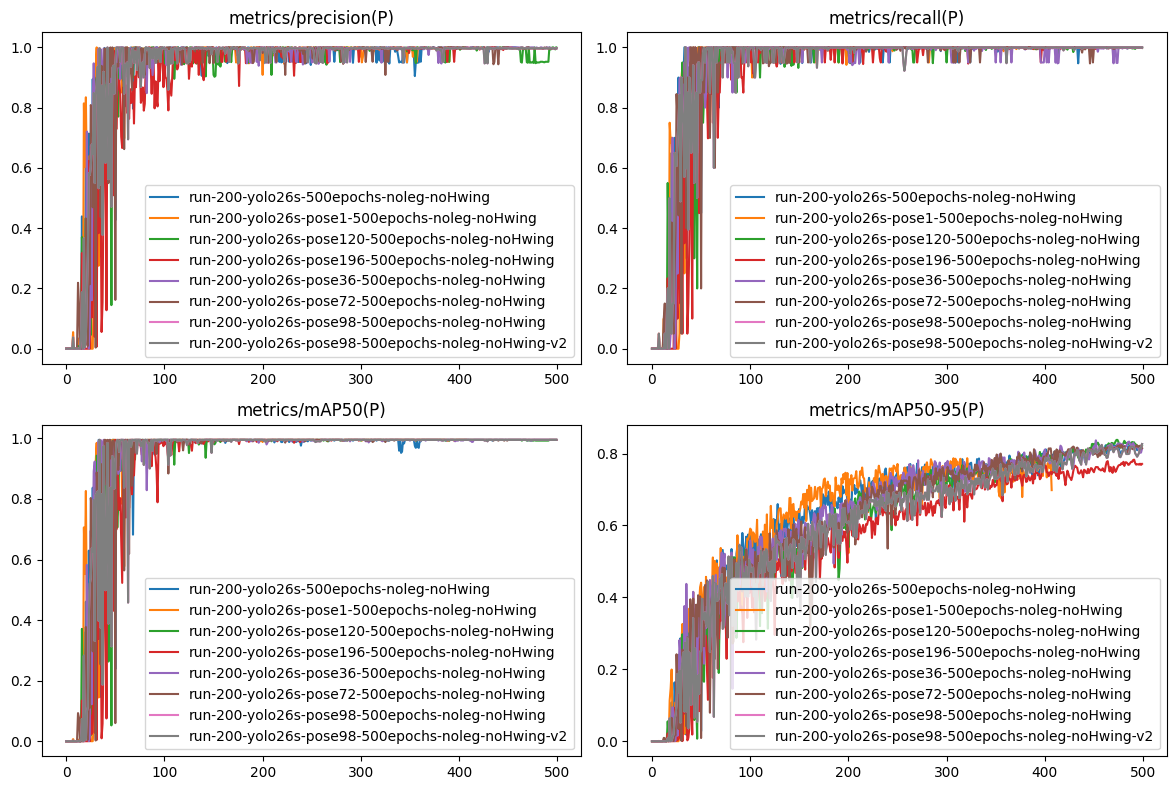

In [6]:
plot_columns(preset_metrics_pose, filter)               

In [3]:
## run the model on a whole folder to get annotations for label-studio
from PIL import Image

PATH_TO_MODEL_RUN = "/home/tombellivier/Documents/CV/CV-for-GRIT/models/runs/pose/run-200-yolo26s-pose98-500epochs-noleg-noHwing"
PATH_TO_IMAGES = "/home/tombellivier/Documents/CV/CV-for-GRIT/databases/hawaii_beetles_images/individual_specimens/16"

model = YOLO(Path(PATH_TO_MODEL_RUN) / "weights" / "best.pt")
with open(Path(PATH_TO_MODEL_RUN) / "args.yaml", "r") as f:
    model_args = yaml.safe_load(f)

model_dataset_path = model_args["data"]

with open(model_dataset_path, "r") as f:
    model_dataset_config = yaml.safe_load(f)

used_keypoint_names = model_dataset_config["kpt_names"][0]

all_images = list(Path(PATH_TO_IMAGES).glob("*.png")) + list(Path(PATH_TO_IMAGES).glob("*.jpe?g"))

all_annotations = []

for img_id in range(len(all_images)):
    all_annotations.append({})
    new_annotation = {"id":str(img_id), "result" : []}

    with Image.open(all_images[img_id]) as i:
        width, height = i.size

    formatted_folder_path = "/data/local-files/?d=" + "%5C".join(str(Path(PATH_TO_IMAGES).resolve()).split("\\")[1:]) + "%5C"
    all_annotations[-1]["id"] = str(img_id)
    all_annotations[-1]["data"] = {"img":formatted_folder_path+str(Path(all_images[img_id]).name)}
    
    res_yolo = model.predict(all_images[img_id], conf=CONF, verbose=True)
    if len(res_yolo[0].keypoints) != 0:
        kpts_pred = res_yolo[0].keypoints.xy[0].cpu().numpy()
        for kp_id in range(len(kpts_pred)):
            new_result = {}
            new_result["original_width"] = width
            new_result["original_height"] = height
            new_result["image_rotation"] = 0
            new_result["value"] = {
                "x" : float(kpts_pred[kp_id][0]) / width * 100,
                "y" : float(kpts_pred[kp_id][1]) / height * 100,
                "width" : 1.48,
                "keypointlabels" : [used_keypoint_names[kp_id]]
            }
            new_result["id"] = str(kp_id)
            new_result["from_name"] = "kp"
            new_result["to_name"] = "img-1"
            new_result["type"] = "keypointlabels"
            new_result["origin"] = "manual" ### tester "automatic"
            new_annotation["result"].append(new_result)
            
    else:
        print("yolo have detected no point in : ", all_images[img_id])
    
    all_annotations[-1]["annotations"] = [new_annotation]

filename = Path(PATH_TO_IMAGES).stem + "_predicted.json"
print(all_annotations)
with open(Path(PATH_TO_IMAGES)/filename, "w") as f:
    json.dump(all_annotations, f, indent=2)



image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/databases/hawaii_beetles_images/individual_specimens/16/IMG_0546_specimen_5_TREOBT_NEON.BET.D20.001625.png: 640x352 1 insects, 4.0ms
Speed: 0.6ms preprocess, 4.0ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 352)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/databases/hawaii_beetles_images/individual_specimens/16/IMG_0539_specimen_4_TREOBT_NEON.BET.D20.003072.png: 640x416 1 insects, 43.2ms
Speed: 0.6ms preprocess, 43.2ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 416)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/databases/hawaii_beetles_images/individual_specimens/16/IMG_0547_specimen_1_TREOBT_NEON.BET.D20.001626.png: 640x512 1 insects, 5.0ms
Speed: 0.7ms preprocess, 5.0ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /home/tombellivier/Documents/CV/CV-for-GRIT/databases/hawaii_beetles_images/individual_specimens/16/IMG_0552_specimen_4_TREOBT_NEON.BET